Starting Phase 1: Adam (5,000 steps)...
Step 0, Loss: 1.084078, L1 Test Error: 0.282003
Step 1000, Loss: 0.061283, L1 Test Error: 0.158771
Step 2000, Loss: 0.021568, L1 Test Error: 0.086660
Step 3000, Loss: 0.010206, L1 Test Error: 0.034959
Step 4000, Loss: 0.009415, L1 Test Error: 0.012333
Step 5000, Loss: 0.017158, L1 Test Error: 0.014304

Starting Phase 2: L-BFGS (Refinement)...

Training Complete in 40.68 seconds.


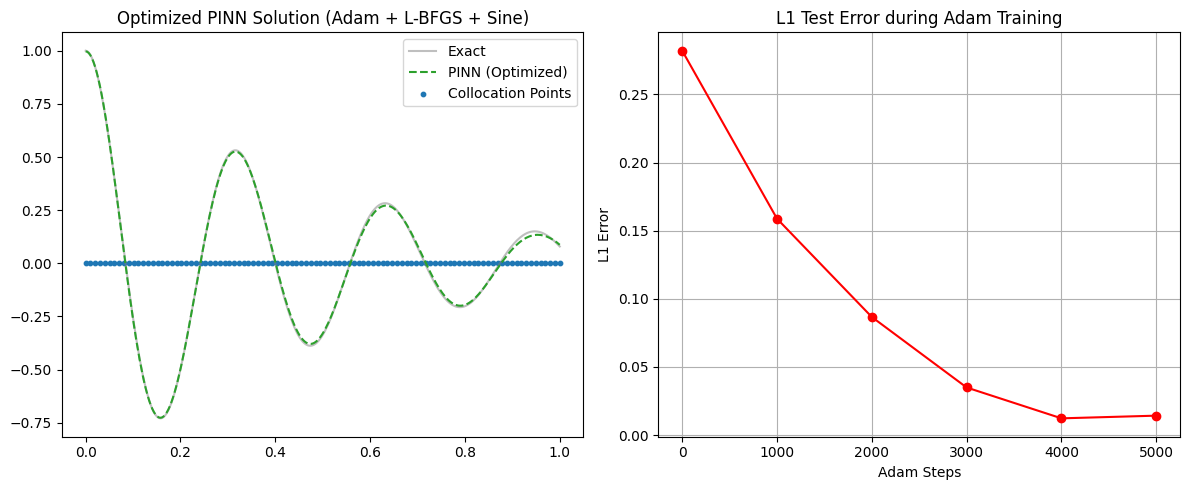

In [2]:
# Save this content into a .ipynb or copy into a Colab cell
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- 1. OPTIMIZED MODEL ARCHITECTURE ---
class FCN(nn.Module):
    """
    Optimized PINN architecture using Sine activation functions.
    Periodic activations converges much faster for oscillatory ODEs.
    """
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        self.fcs = nn.Linear(N_INPUT, N_HIDDEN)
        self.fch = nn.ModuleList([nn.Linear(N_HIDDEN, N_HIDDEN) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = torch.sin(self.fcs(x)) # Sine activation for physics-informed speed
        for layer in self.fch:
            x = torch.sin(layer(x))
        x = self.fce(x)
        return x

def exact_solution(d, w0, t):
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    u = torch.exp(-d*t) * 2 * A * torch.cos(phi + w * t)
    return u

# --- 2. SETUP DATA & PARAMETERS ---
torch.manual_seed(123)
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0, 1, 300).view(-1, 1)
u_exact = exact_solution(d, w0, t_test)

# Define training points
t_boundary = torch.tensor([[0.0]], requires_grad=True)
t_physics = torch.linspace(0, 1, 100).view(-1, 1).requires_grad_(True) # Increased physics points

pinn = FCN(1, 1, 64, 4) # Denser network: N_HIDDEN=64, N_LAYERS=4

# --- 3. HYBRID OPTIMIZATION STRATEGY ---
# Phase 1: Adam for quick exploration
optimizer_adam = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# Phase 2: L-BFGS for rapid convergence to high accuracy
# optimizer_lbfgs = torch.optim.LBFGS(
#     pinn.parameters(),
#     lr=1.0,
#     max_iter=50,
#     tolerance_grad=1e-7,
#     line_search_fn="strong_wolfe"
# )

def compute_loss():
    # Boundary/Initial Conditions
    u_b = pinn(t_boundary)
    dudt_b = torch.autograd.grad(u_b, t_boundary, torch.ones_like(u_b), create_graph=True)[0]
    loss_boundary = (u_b - 1.0)**2 + (dudt_b - 0.0)**2

    # Physics Residual
    u_p = pinn(t_physics)
    dudt_p = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    d2udt2_p = torch.autograd.grad(dudt_p, t_physics, torch.ones_like(dudt_p), create_graph=True)[0]
    loss_physics = torch.mean((1.0*d2udt2_p + mu*dudt_p + k*u_p)**2)

    return loss_boundary, loss_physics

# --- 4. TRAINING LOOP ---
start_time = time.time()

l1_errors_adam = []
adam_steps = []

print("Starting Phase 1: Adam (5,000 steps)...")
for i in range(5001): # Increased Adam steps
    optimizer_adam.zero_grad()
    l_b, l_p = compute_loss()
    loss = l_b + 1e-4 * l_p # Scaled physics loss for stability
    loss.backward()
    optimizer_adam.step()

    if i % 1000 == 0:
        # Calculate L1 test error
        with torch.no_grad():
            u_pred_test = pinn(t_test)
            l1_error = torch.abs(u_pred_test - u_exact).mean().item()
        l1_errors_adam.append(l1_error)
        adam_steps.append(i)
        print(f"Step {i}, Loss: {loss.item():.6f}, L1 Test Error: {l1_error:.6f}")

# print("\nStarting Phase 2: L-BFGS (Refinement)...")
# def closure():
#     optimizer_lbfgs.zero_grad()
#     l_b, l_p = compute_loss()
#     loss = l_b + 1e-4 * l_p
#     loss.backward()
#     return loss

# optimizer_lbfgs.step(closure) # Replaces thousands of Adam steps

total_time = time.time() - start_time
print(f"\nTraining Complete in {total_time:.2f} seconds.")

# --- 5. VISUALIZATION ---
u_pred = pinn(t_test).detach()
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Subplot for PINN solution
plt.plot(t_test, u_exact, label="Exact", color="grey", alpha=0.5)
plt.plot(t_test, u_pred, label="PINN (Optimized)", color="tab:green", linestyle="--")
plt.scatter(t_physics.detach(), torch.zeros_like(t_physics), s=10, label="Collocation Points")
plt.title("Optimized PINN Solution (Adam Only)") # Changed title
plt.legend()

plt.subplot(1, 2, 2) # Subplot for L1 Error during Adam training
plt.plot(adam_steps, l1_errors_adam, marker='o', linestyle='-', color='red')
plt.title("L1 Test Error during Adam Training")
plt.xlabel("Adam Steps")
plt.ylabel("L1 Error")
plt.grid(True)

plt.tight_layout()
plt.show()